In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import time
import random
import re

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# Check if torch will use Apple Silicon GPU

if torch.backends.mps.is_available():
    mps_device = torch.device("mps")
    x = torch.ones(1, device=mps_device)
    print (x)
else:
    print ("MPS device not found.")

tensor([1.], device='mps:0')


In [3]:
movielens_data_dir = "ml-32m"

In [4]:
num_ratings_to_read = 35_000_000

df_ratings = pd.read_csv(movielens_data_dir + '/ratings.csv', nrows=num_ratings_to_read)

In [5]:
len(df_ratings)

33832162

In [6]:
# clean the ratings data
df_ratings = df_ratings.dropna()
df_ratings['movieId'] = df_ratings['movieId'].astype(int, copy=False)

In [7]:
df_ratings.head(5)

,userId,movieId,rating,timestamp
0,1,1,4.0,1225734739
1,1,110,4.0,1225865086
2,1,158,4.0,1225733503
3,1,260,4.5,1225735204
4,1,356,5.0,1225735119


In [8]:
df_movies = pd.read_csv(movielens_data_dir + '/movies.csv')

In [9]:
df_movies.head(3)

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance


In [10]:
df_tags = pd.read_csv(movielens_data_dir + '/tags.csv')

In [11]:
df_tags['tag'] = df_tags['tag'].str.lower()
df_tags['tag'] = df_tags['tag'].str.strip()

In [12]:
df_tags.head(3)

,userId,movieId,tag,timestamp
0,10,260,good vs evil,1430666558
1,10,260,harrison ford,1430666505
2,10,260,sci-fi,1430666538


In [71]:
counts = df_tags.groupby('tag').size().reset_index(name='count')
df_tags_sorted_counts = counts.sort_values(by='count', ascending=False)

MIN_NUM_TAGS = 1000
df_tags_final_counts = df_tags_sorted_counts[df_tags_sorted_counts['count'] > MIN_NUM_TAGS]  
df_tags_final_counts.head(3)

,tag,count
110730,sci-fi,14917
8556,atmospheric,12776
2299,action,11754


In [72]:
# Get the final tags we want to use as movie features
final_movie_tags = set(df_tags_final_counts['tag'].tolist())
len(final_movie_tags)

306

# Movie Feature Processing

In [235]:
# let's only work with movies with enough ratings.

min_ratings_per_movie = 3_000

# get the number of ratings per movie
df_movies_to_num_ratings = df_ratings.groupby('movieId', as_index=False)['rating'].count()
print("total movies in corpus: ", len(df_movies_to_num_ratings))

df_movies_to_num_ratings = df_movies_to_num_ratings.sort_values(by=['rating'], ascending=False)
df_movies_to_num_ratings = df_movies_to_num_ratings[df_movies_to_num_ratings['rating'] > min_ratings_per_movie]
print("movies with enough ratings: ", len(df_movies_to_num_ratings))

# get list of the top movies by number of ratings.
top_movies = df_movies_to_num_ratings.movieId.tolist()

total movies in corpus:  83239
movies with enough ratings:  2268


In [236]:
# keep a map of movieId to number of ratings.
movieId_to_num_ratings = {}
movieId_list = df_movies_to_num_ratings.movieId.tolist()
rating_list = df_movies_to_num_ratings.rating.tolist()
for i in range(len(movieId_list)):
  movieId_to_num_ratings[movieId_list[i]] = rating_list[i]

In [237]:
# map movieId to title
movieId_to_title = {}
title_to_movieId = {}

# map moveiId to year
movieId_to_year = {}

movieId_list = df_movies.movieId.tolist()
title_list = df_movies.title.tolist()

for i in range(len(movieId_list)):
  movieId = movieId_list[i]
  title = title_list[i]

  movieId_to_title[movieId] = title
  title_to_movieId[title] = movieId

  match = re.search(r"\(\d+\)\s*$", title)
  if match:
    year = title[match.start()+1:match.end()-1]
    movieId_to_year[movieId] = year
  else:
    movieId_to_year[movieId] = -1

In [238]:
# keep track of the number of unique year values we see in movieId_to_year
year_to_num_movies = {}
for movieId,year in movieId_to_year.items():
  if year not in year_to_num_movies:
    year_to_num_movies[year] = 0
  year_to_num_movies[year] += 1

In [239]:
# print the top movies
for movieId in top_movies[0:10]:
  print(movieId, movieId_to_title[movieId], movieId_to_num_ratings[movieId])

318 Shawshank Redemption, The (1994) 122296
356 Forrest Gump (1994) 113581
296 Pulp Fiction (1994) 108756
2571 Matrix, The (1999) 107056
593 Silence of the Lambs, The (1991) 101802
260 Star Wars: Episode IV - A New Hope (1977) 97202
2959 Fight Club (1999) 86207
527 Schindler's List (1993) 84232
480 Jurassic Park (1993) 83026
1196 Star Wars: Episode V - The Empire Strikes Back (1980) 80200


In [240]:
# map movieId to list of genres for that movie
genres = set()
movieId_to_genres = {}

movieId_list = df_movies.movieId.tolist()
genre_list = df_movies.genres.tolist()

for i in range(len(movieId_list)):
  movieId = movieId_list[i]
  if movieId not in top_movies:
    continue

  movieId_to_genres[movieId] = set()

  for genre in genre_list[i].split('|'):
    genres.add(genre)
    movieId_to_genres[movieId].add(genre)

In [241]:
movieId_to_genres[title_to_movieId['Matrix, The (1999)']]

{'Action', 'Sci-Fi', 'Thriller'}

In [242]:
# map movieId to the counts of tags for that movie
movieId_to_tag_to_count = {}

movieId_list = df_tags.movieId.tolist()
tag_list = df_tags.tag.tolist()

for i in range(len(movieId_list)):
  movieId = movieId_list[i]
  if movieId not in top_movies:
    continue
      
  if movieId not in movieId_to_tag_to_count:
    movieId_to_tag_to_count[movieId] = {}

  tag = tag_list[i]
  if tag not in final_movie_tags:
    continue
  if tag not in movieId_to_tag_to_count[movieId]:
    movieId_to_tag_to_count[movieId][tag] = 0

  movieId_to_tag_to_count[movieId][tag] += 1

In [243]:
# movieId_to_tag_to_count[title_to_movieId['Matrix, The (1999)']]

In [244]:
# for every movie, get the avg rating
df_movies_to_avg_rating = df_ratings.groupby('movieId', as_index=False)['rating'].mean()

movieId_to_avg_rating = {}

movieId_list = df_movies_to_avg_rating.movieId.tolist()
rating_list = df_movies_to_avg_rating.rating.tolist()
for i in range(len(movieId_list)):
  if movieId_list[i] not in top_movies: continue
  movieId_to_avg_rating[movieId_list[i]] = rating_list[i]

In [245]:
# build ITEM movieId embedding mapping
item_emb_movieId_to_i = {s:i for i,s in enumerate(top_movies)}
item_emb_i_to_movieId = {i:s for s,i in item_emb_movieId_to_i.items()}

In [246]:
# build ITEM genre feature context
genre_to_i = {s:i for i,s in enumerate(genres)}
i_to_genre = {i:s for s,i in genre_to_i.items()}

In [247]:
# build ITEM year embedding mapping
year_to_i = {s:i for i,s in enumerate(year_to_num_movies.keys())}
i_to_year = {i:s for s,i in year_to_i.items()}

In [248]:
# build ITEM tag feature context
tag_to_i = {s:i for i,s in enumerate(final_movie_tags)}
i_to_tag = {i:s for s,i in tag_to_i.items()}

# User Feature Processing

In [249]:
# user_context_movies is no longer needed.
# The user's watch history is now represented as avg pooling over shared item embeddings.
# This saves substantial memory as we no longer need a multi-hot vector per training example.


In [250]:
df_ratings_final = df_ratings[df_ratings.movieId.isin(top_movies)]
df_ratings_final = df_ratings_final.sort_values(['userId', 'timestamp'], ascending=[True, True])

In [251]:
df_ratings_final.head(3)

,userId,movieId,rating,timestamp
2,1,158,4.0,1225733503
37,1,4896,4.0,1225733516
6,1,596,4.0,1225733524


In [252]:
# aggregate dataframe down into one row per user and list of their movies and ratings.
df_ratings_final = df_ratings_final.groupby('userId').agg(
    {'movieId': lambda x: list(x),
     'rating': lambda y: list(y),
     'timestamp': lambda z: list(z)
    }).reset_index()

In [253]:
df_ratings_final.head(3)

,userId,movieId,rating,timestamp
0,1,"[158, 4896, 596, 1396, 1376, 1909, 2336, 1293,...","[4.0, 4.0, 4.0, 3.0, 3.0, 3.0, 3.5, 2.0, 3.0, ...","[1225733503, 1225733516, 1225733524, 122573353..."
1,2,"[592, 590, 150, 296, 380, 165, 349, 588, 153, ...","[3.0, 5.0, 5.0, 5.0, 4.0, 4.0, 4.0, 4.0, 3.0, ...","[835815551, 835815552, 835815553, 835815554, 8..."
2,3,"[2959, 318, 79132, 858, 177765, 296, 116797, 9...","[5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, ...","[1536173840, 1536173843, 1536173845, 153617384..."


In [254]:
# The user context is now ONLY the genre avg ratings.
# The watch history (movie IDs) is stored separately and handled via avg pooling in the model.
user_context_size = len(genres)

user_context_genre_avg_rating_to_i = {s:i for i,s in enumerate(list(genres))}
user_context_i_to_genre_avg_rating = {i:s for s,i in user_context_genre_avg_rating_to_i.items()}


# Generate Training Examples

In [255]:
# simulate training examples by masking out some of the user's watched movies from their context, and using them as labels.
# we do not want the 'movie to predict' in their watch history, as we are trying to simulate the following:
# given the user's watch history, what would they rate this new movie?
# NOTE: this is not the same as a train/test split. This is just simulating how training examples would look like on a movie platform.

# <improve>
# will need large refactor here

percent_ratings_as_watch_history = 0.9

min_ratings_per_user = 20 # ignore users with too few movie watches
max_ratings_per_user = 500 # ignore users with way too many movie watches
too_few_ratings = 0
too_many_ratings = 0

user_to_movie_to_rating_WATCH_HISTORY = {}
user_to_movie_to_rating_LABEL = {}
user_to_movie_to_timestamp_LABEL = {}

# loop over each column as this is much, much faster than going row by row.
user_list = df_ratings_final['userId'].tolist()
movieId_list_list = df_ratings_final['movieId'].tolist()
rating_list_list = df_ratings_final['rating'].tolist()
timestamp_list_list = df_ratings_final['timestamp'].tolist()

for i in range(len(user_list)):
  userId = user_list[i]
  movieId_list = movieId_list_list[i]
  rating_list = rating_list_list[i]
  timestamp_list = timestamp_list_list[i]

  num_rated_movies = len(movieId_list)

  # ignore users with too few or too many ratings.
  if num_rated_movies < min_ratings_per_user:
    too_few_ratings += 1
    continue
  if num_rated_movies > max_ratings_per_user:
    too_many_ratings += 1
    continue

  # set up training example maps.
  user_to_movie_to_rating_WATCH_HISTORY[userId] = {}
  user_to_movie_to_rating_LABEL[userId] = {}
  user_to_movie_to_timestamp_LABEL[userId] = {}

  # put earlier watched movies into user's watch history (features) and leave later watched movies as labels to predict.
  rated_movies = list(zip(movieId_list, rating_list, timestamp_list))
  for movieId,rating,timestamp in rated_movies[:int(num_rated_movies * percent_ratings_as_watch_history)]:
    user_to_movie_to_rating_WATCH_HISTORY[userId][movieId] = rating
  for movieId,rating,timestamp in rated_movies[int(num_rated_movies * percent_ratings_as_watch_history):]:
    user_to_movie_to_rating_LABEL[userId][movieId] = rating
    user_to_movie_to_timestamp_LABEL[userId][movieId] = timestamp

In [256]:
len(user_list), len(user_to_movie_to_rating_WATCH_HISTORY.keys()), too_few_ratings, too_many_ratings

(329449, 188653, 133159, 7637)

In [257]:
# for every user, get their avg rating.
# this will help us debias each user's rating.
user_to_avg_rating = {}

# NOTE: only use ratings from their synthetic watch history.
for user in user_to_movie_to_rating_WATCH_HISTORY.keys():
  user_to_avg_rating[user] = 0
  for movieId in user_to_movie_to_rating_WATCH_HISTORY[user].keys():
    user_to_avg_rating[user] += user_to_movie_to_rating_WATCH_HISTORY[user][movieId]

  user_to_avg_rating[user] /= len(user_to_movie_to_rating_WATCH_HISTORY[user].keys())

In [258]:
user_to_avg_rating[1]

4.020833333333333

In [259]:
# for every user, get the avg rating for every genre
user_to_genre_to_stat = {}

# NOTE: only use ratings from their synthetic watch history.
for user in user_to_movie_to_rating_WATCH_HISTORY.keys():
  user_to_genre_to_stat[user] = {}
  for movieId in user_to_movie_to_rating_WATCH_HISTORY[user].keys():
    for genre in movieId_to_genres[movieId]:
      if genre not in user_to_genre_to_stat[user]:
        user_to_genre_to_stat[user][genre] = {
            'NUM_RATINGS': 0,
            'SUM_RATINGS': 0,
        }

      user_to_genre_to_stat[user][genre]['NUM_RATINGS'] += 1
      user_to_genre_to_stat[user][genre]['SUM_RATINGS'] += user_to_movie_to_rating_WATCH_HISTORY[user][movieId]

for user in user_to_genre_to_stat.keys():
  for genre in user_to_genre_to_stat[user].keys():
    num_ratings = user_to_genre_to_stat[user][genre]['NUM_RATINGS']
    sum_ratings = user_to_genre_to_stat[user][genre]['SUM_RATINGS']
    user_to_genre_to_stat[user][genre]['AVG_RATING'] = sum_ratings / num_ratings


In [260]:
# Build per-user genre context and watch history.
#
# user_to_context:       genre avg ratings only — shape (len(genres),) per user
# user_to_watch_history: list of emb_idx for the most recent N watched movies

MAX_HISTORY_LEN = 50  # cap to most recent N movies; older watches add little signal via avg pool

user_to_context = {}
user_to_watch_history = {}

for user in user_to_movie_to_rating_WATCH_HISTORY.keys():
    # Genre context
    context = [0.0] * user_context_size
    for genre in user_to_genre_to_stat[user].keys():
        context[user_context_genre_avg_rating_to_i[genre]] = float(
            user_to_genre_to_stat[user][genre]['AVG_RATING'] - user_to_avg_rating[user]
        )
    user_to_context[user] = context

    # Watch history: embedding indices only, capped to most recent N
    watch_ids = [
        item_emb_movieId_to_i[movieId]
        for movieId in user_to_movie_to_rating_WATCH_HISTORY[user].keys()
        if movieId in item_emb_movieId_to_i
    ]
    user_to_watch_history[user] = watch_ids[-MAX_HISTORY_LEN:]


In [261]:
# for every movie, create a training example feature GENRE context vector lookup
# it will contain the movie's genres.
movieId_to_genre_context = {}
for movieId in top_movies:
  genre_context = [0.0] * len(genres)

  for genre in movieId_to_genres[movieId]:
    genre_context[genre_to_i[genre]] = float(1.0)

  movieId_to_genre_context[movieId] = genre_context

In [262]:
# for every movie, create a training example feature TAG context vector lookup
# it will contain the movie's tags.
movieId_to_tag_context = {}
for movieId in top_movies:
  tag_context = [0.0] * len(final_movie_tags)

  for tag,count in movieId_to_tag_to_count[movieId].items():
    tag_context[tag_to_i[tag]] = float(count)

  movieId_to_tag_context[movieId] = tag_context

# Build Datasets

In [263]:
# Prepare the buckets for our timestamps so we can use them as categorical features
timestamp_num_bins = 1500
timestamp_bins = torch.tensor(np.linspace(df_ratings['timestamp'].min(), df_ratings['timestamp'].max(), timestamp_num_bins))

In [264]:
# PAD_IDX is one beyond the last valid movie index (0..top_movies_len-1).
# The Embedding layer's padding_idx=PAD_IDX will zero-out those positions automatically.
PAD_IDX = len(top_movies)

def pad_history_batch(histories):
    """Pad variable-length watch histories to the batch max length.
    Returns a (batch, max_hist_len) long tensor. Padded positions are PAD_IDX.
    """
    max_len = max((len(h) for h in histories), default=1)
    padded = torch.full((len(histories), max_len), PAD_IDX, dtype=torch.long)
    for i, hist in enumerate(histories):
        if len(hist) > 0:
            padded[i, :len(hist)] = torch.tensor(hist, dtype=torch.long)
    return padded

def build_dataset(users):
    X = []
    X_history = []   # list of emb_idx lists (variable length per user)
    timestamp = []
    target_movieId = []
    target_movieId_genre_context = []
    target_movieId_tag_context = []
    target_movieId_year = []
    Y = []

    for user in users:
        for movieId in user_to_movie_to_rating_LABEL[user].keys():
            X.append(user_to_context[user])
            X_history.append(user_to_watch_history[user])
            timestamp.append(user_to_movie_to_timestamp_LABEL[user][movieId])
            target_movieId.append(item_emb_movieId_to_i[movieId])
            target_movieId_genre_context.append(movieId_to_genre_context[movieId])
            target_movieId_tag_context.append(movieId_to_tag_context[movieId])
            target_movieId_year.append(year_to_i[movieId_to_year[movieId]])
            Y.append(float(user_to_movie_to_rating_LABEL[user][movieId] - user_to_avg_rating[user]))

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    target_movieId = torch.tensor(target_movieId)
    target_movieId_genre_context = torch.tensor(target_movieId_genre_context)
    target_movieId_tag_context = torch.tensor(target_movieId_tag_context)
    target_movieId_year = torch.tensor(target_movieId_year)
    timestamp = torch.bucketize(torch.tensor(timestamp), timestamp_bins, right=False)

    return X, X_history, timestamp, Y, target_movieId, target_movieId_genre_context, target_movieId_tag_context, target_movieId_year


In [265]:
# user users with enough ratings to predict to be useful for model learning.
final_users = []

for user in user_to_movie_to_rating_LABEL.keys():
  num_ratings = len(user_to_movie_to_rating_LABEL[user])

  # having at least 2 watched movies in the user's LABEL split means they have watched at least 20 movies
  # 18 of these movies are used for the user's watch history
  if num_ratings >= 2 and num_ratings < 500:
    final_users.append(user)

len(final_users)

188653

In [266]:
# split users into train and validation users
percent_users_train = 0.9

random.shuffle(final_users)

train_users = final_users[:int(len(final_users) * percent_users_train)]
validation_users = final_users[int(len(final_users) * percent_users_train):]

In [267]:
X_train, X_history_train, timestamp_train, Y_train, target_movieId_train, target_movieId_genre_context_train, target_movieId_tag_context_train, target_movieId_year_train = build_dataset(train_users)
X_val,   X_history_val,   timestamp_val,   Y_val,   target_movieId_val,   target_movieId_genre_context_val,   target_movieId_tag_context_val,   target_movieId_year_val   = build_dataset(validation_users)


In [268]:
print("train:")
print("  X_train (genre context):               ", X_train.shape)
print("  X_history_train (list of lists):        ", f"{len(X_history_train)} examples, variable-length histories")
print("  timestamp_train:                        ", timestamp_train.shape)
print("  Y_train:                                ", Y_train.shape)
print("  target_movieId_train:                   ", target_movieId_train.shape)
print("  target_movieId_genre_context_train:     ", target_movieId_genre_context_train.shape)
print("  target_movieId_tag_context_train:       ", target_movieId_tag_context_train.shape)
print("  target_movieId_year_train:              ", target_movieId_year_train.shape)
print()
print("val:")
print("  X_val (genre context):                 ", X_val.shape)
print("  X_history_val (list of lists):          ", f"{len(X_history_val)} examples, variable-length histories")
hist_lens = [len(h) for h in X_history_train]
print(f"  history length stats — min: {min(hist_lens)}  max: {max(hist_lens)}  mean: {sum(hist_lens)/len(hist_lens):.1f}")


train:
  X_train (genre context):                torch.Size([1838377, 20])
  X_history_train (list of lists):         1838377 examples, variable-length histories
  timestamp_train:                         torch.Size([1838377])
  Y_train:                                 torch.Size([1838377])
  target_movieId_train:                    torch.Size([1838377])
  target_movieId_genre_context_train:      torch.Size([1838377, 20])
  target_movieId_tag_context_train:        torch.Size([1838377, 306])
  target_movieId_year_train:               torch.Size([1838377])

val:
  X_val (genre context):                  torch.Size([202019, 20])
  X_history_val (list of lists):           202019 examples, variable-length histories
  history length stats — min: 18  max: 50  mean: 47.3


# Build our Two Tower Model

In [269]:
'''
User side:
  avg_pool(item_emb[watched_movies])  --> history_emb (item_movieId_embedding_size)
                                              \
  genre_avg_ratings --> user_genre_tower       --> cat --> user_combined
                                              /
  timestamp_emb --> ts_tower             ts_emb

Item side:
  movie_genres --> genre_tower \
  movie_tags   --> tag_tower    \
                                --> cat --> item_combined
  movie_id_emb --> item_tower  /
  movie_year   --> year_tower /

Prediction: dot_product(user_combined, item_combined)

Dimension constraint:
  user: item_movieId_embedding_size + user_genre_embedding_size + timestamp_feature_embedding_size
  item: item_genre_embedding_size + item_tag_embedding_size + item_movieId_embedding_size + item_year_embedding_size
  both must be equal.
'''

class MovieRecommender(nn.Module):
    def __init__(self,
                 genres_len,
                 tags_len,
                 top_movies_len,
                 all_years_len,
                 timestamp_num_bins,
                 item_genre_embedding_size=10,
                 item_tag_embedding_size=40,
                 item_movieId_embedding_size=40,
                 item_year_embedding_size=10,
                 user_genre_embedding_size=50,
                 timestamp_feature_embedding_size=10,
                ):
        """
        Args:
            genres_len (int): Number of unique genres.
            tags_len (int): Number of unique tags.
            top_movies_len (int): Number of movies in the embedding table.
            all_years_len (int): Number of unique release years.
            timestamp_num_bins (int): Number of timestamp buckets.
            item_genre_embedding_size (int): Output size of the genre tower.
            item_tag_embedding_size (int): Output size of the tag tower.
            item_movieId_embedding_size (int): Embedding dim for movie IDs.
                Shared between item tower and user history avg pooling.
            item_year_embedding_size (int): Output size of the year tower.
            user_genre_embedding_size (int): Output size of the user genre tower.
                Must satisfy: item_movieId_embedding_size + user_genre_embedding_size
                              + timestamp_feature_embedding_size
                              == item_genre_embedding_size + item_tag_embedding_size
                                 + item_movieId_embedding_size + item_year_embedding_size
            timestamp_feature_embedding_size (int): Embedding dim for timestamps.
        """
        super().__init__()

        # PAD index sits one beyond valid indices (0 .. top_movies_len-1)
        self.pad_idx = top_movies_len

        # ── Shared item embedding ─────────────────────────────────────────────
        # Used by BOTH the item tower (target movie) and the user history avg pool.
        # top_movies_len + 1 rows to accommodate pad_idx; padding_idx zeroes that row.
        self.item_embedding_lookup = nn.Embedding(
            top_movies_len + 1, item_movieId_embedding_size, padding_idx=top_movies_len
        )
        self.item_embedding_tower = nn.Sequential(
            nn.Linear(item_movieId_embedding_size, item_movieId_embedding_size),
            nn.Tanh()
        )

        # ── Item feature towers ───────────────────────────────────────────────
        self.item_genre_tower = nn.Sequential(
            nn.Linear(genres_len, item_genre_embedding_size),
            nn.Tanh()
        )
        self.item_tag_tower = nn.Sequential(
            nn.Linear(tags_len, item_tag_embedding_size),
            nn.Tanh()
        )
        self.year_embedding_lookup = nn.Embedding(all_years_len, item_year_embedding_size)
        self.year_embedding_tower = nn.Sequential(
            nn.Linear(item_year_embedding_size, item_year_embedding_size),
            nn.Tanh()
        )

        # ── User towers ───────────────────────────────────────────────────────
        # Genre avg-rating tower (no movie IDs here — those go through avg pooling)
        self.user_genre_tower = nn.Sequential(
            nn.Linear(genres_len, user_genre_embedding_size),
            nn.Tanh()
        )
        self.timestamp_embedding_lookup = nn.Embedding(timestamp_num_bins, timestamp_feature_embedding_size)
        self.timestamp_embedding_tower = nn.Sequential(
            nn.Linear(timestamp_feature_embedding_size, timestamp_feature_embedding_size),
            nn.Tanh()
        )

        # ── Dimension check ───────────────────────────────────────────────────
        user_side = item_movieId_embedding_size + user_genre_embedding_size + timestamp_feature_embedding_size
        item_side = item_genre_embedding_size + item_tag_embedding_size + item_movieId_embedding_size + item_year_embedding_size
        if user_side != item_side:
            raise ValueError(
                f"User embedding size ({user_side} = history {item_movieId_embedding_size} + "
                f"genre {user_genre_embedding_size} + timestamp {timestamp_feature_embedding_size}) "
                f"must match item embedding size ({item_side}). Adjust user_genre_embedding_size."
            )

        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.xavier_uniform_(module.weight, gain=0.01)
            if module.bias is not None:
                torch.nn.init.constant_(module.bias, 0)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.xavier_uniform_(module.weight, gain=0.01)

    def forward(self, user_genre_contexts, user_watch_history, timestamps,
                movie_genres, movie_tags, years, target_movieId):
        """
        Args:
            user_genre_contexts (Tensor): (batch, genres_len)   — per-genre avg rating
            user_watch_history  (Tensor): (batch, max_hist_len) — padded movie ID indices
            timestamps          (Tensor): (batch,)              — bucketized timestamp indices
            movie_genres        (Tensor): (batch, genres_len)   — target movie genre features
            movie_tags          (Tensor): (batch, tags_len)     — target movie tag features
            years               (Tensor): (batch,)              — target movie year indices
            target_movieId      (Tensor): (batch,)              — target movie ID indices
        """
        # ── User history tower (unweighted avg pool over shared item embeddings) ─────
        history_embs = self.item_embedding_lookup(user_watch_history)
        # (batch, max_hist_len, item_movieId_embedding_size)

        # Mask padding positions so they don't contribute to the mean.
        # padding_idx zeros out the embedding vectors but we still need correct counts.
        mask = (user_watch_history != self.pad_idx).float().unsqueeze(-1)   # (batch, max_hist_len, 1)
        valid_count = mask.sum(dim=1).clamp(min=1)                           # (batch, 1)
        history_emb = (history_embs * mask).sum(dim=1) / valid_count         # (batch, item_movieId_embedding_size)

        # ── User genre tower ──────────────────────────────────────────────────
        genre_emb = self.user_genre_tower(user_genre_contexts)              # (batch, user_genre_embedding_size)

        # ── Timestamp tower ───────────────────────────────────────────────────
        ts_emb = self.timestamp_embedding_tower(
            self.timestamp_embedding_lookup(timestamps)
        )                                                                    # (batch, timestamp_feature_embedding_size)

        # ── Combine user side ─────────────────────────────────────────────────
        user_combined = torch.cat([history_emb, genre_emb, ts_emb], dim=1)
        # (batch, item_movieId_embedding_size + user_genre_embedding_size + timestamp_feature_embedding_size)

        # ── Item tower ────────────────────────────────────────────────────────
        item_genre_emb = self.item_genre_tower(movie_genres)                # (batch, item_genre_embedding_size)
        item_tag_emb   = self.item_tag_tower(movie_tags)                    # (batch, item_tag_embedding_size)
        item_emb       = self.item_embedding_tower(
            self.item_embedding_lookup(target_movieId)
        )                                                                    # (batch, item_movieId_embedding_size)
        year_emb       = self.year_embedding_tower(
            self.year_embedding_lookup(years)
        )                                                                    # (batch, item_year_embedding_size)

        item_combined = torch.cat([item_genre_emb, item_tag_emb, item_emb, year_emb], dim=1)
        # (batch, item_genre_embedding_size + item_tag_embedding_size + item_movieId_embedding_size + item_year_embedding_size)

        # ── Dot product prediction ────────────────────────────────────────────
        preds = torch.einsum('ij, ij -> i', user_combined, item_combined)

        return preds


# Training Loop

In [270]:
# --- Training Loop ---

# Define model hyper-parameters
item_genre_embedding_size = 10
item_tag_embedding_size   = 40
item_movieId_embedding_size = 40
item_year_embedding_size  = 10

# Constraint:
#   item_movieId_embedding_size + user_genre_embedding_size + timestamp_feature_embedding_size
#   == item_genre_embedding_size + item_tag_embedding_size + item_movieId_embedding_size + item_year_embedding_size
#   40 + user_genre_embedding_size + 10 == 10 + 40 + 40 + 10 == 100
#   => user_genre_embedding_size = 50
user_genre_embedding_size       = 50
timestamp_feature_embedding_size = 10

# Instantiate the MovieRecommender model
model = MovieRecommender(
    genres_len=len(genres),
    tags_len=len(final_movie_tags),
    top_movies_len=len(top_movies),
    all_years_len=len(year_to_num_movies),
    timestamp_num_bins=timestamp_num_bins,
    item_genre_embedding_size=item_genre_embedding_size,
    item_tag_embedding_size=item_tag_embedding_size,
    item_movieId_embedding_size=item_movieId_embedding_size,
    item_year_embedding_size=item_year_embedding_size,
    user_genre_embedding_size=user_genre_embedding_size,
    timestamp_feature_embedding_size=timestamp_feature_embedding_size,
)

# Print the total number of trainable parameters in the model
print(f"Number of trainable parameters: {sum(p.nelement() for p in model.parameters() if p.requires_grad)}")


Number of trainable parameters: 123080


In [271]:
USE_GPU = False

if USE_GPU:
    mps_device = torch.device("mps")
    
    # Move the model to the GPU
    model.to(mps_device)
    
    # move validation data to MPS
    X_val = X_val.to(mps_device)
    timestamp_val = timestamp_val.to(mps_device)
    target_movieId_genre_context_val = target_movieId_genre_context_val.to(mps_device)
    target_movieId_tag_context_val = target_movieId_tag_context_val.to(mps_device)
    target_movieId_year_val = target_movieId_year_val.to(mps_device)
    target_movieId_val = target_movieId_val.to(mps_device)
    Y_val = Y_val.to(mps_device)
    
    # move training data to MPS
    X_train = X_train.to(mps_device)
    timestamp_train = timestamp_train.to(mps_device)
    target_movieId_genre_context_train = target_movieId_genre_context_train.to(mps_device)
    target_movieId_tag_context_train = target_movieId_tag_context_train.to(mps_device)
    target_movieId_year_train = target_movieId_year_train.to(mps_device)
    target_movieId_train = target_movieId_train.to(mps_device)
    Y_train = Y_train.to(mps_device)
else:
    # move validation data to CPU
    X_val = X_val.cpu()
    timestamp_val = timestamp_val.cpu()
    target_movieId_genre_context_val = target_movieId_genre_context_val.cpu()
    target_movieId_tag_context_val = target_movieId_tag_context_val.cpu()
    target_movieId_year_val = target_movieId_year_val.cpu()
    target_movieId_val = target_movieId_val.cpu()
    Y_val = Y_val.cpu()
    
    # move training data to CPU
    X_train = X_train.cpu()
    timestamp_train = timestamp_train.cpu()
    target_movieId_genre_context_train = target_movieId_genre_context_train.cpu()
    target_movieId_tag_context_train = target_movieId_tag_context_train.cpu()
    target_movieId_year_train = target_movieId_year_train.cpu()
    target_movieId_train = target_movieId_train.cpu()
    Y_train = Y_train.cpu()

In [272]:
# Set the loss function (Mean Squared Error Loss for regression)
loss_fn = torch.nn.MSELoss()

# Set the optimizer (Stochastic Gradient Descent)
# It will manage the updates to all parameters in `model.parameters()`
optimizer = torch.optim.SGD(model.parameters(), lr=0.005, momentum=0.9)

# Training configuration
minibatch_size = 64
loss_train = [] # To store training loss for each step
loss_val = []   # To store validation loss for full validation runs

log_every = 10_000      # How often to perform a full validation run and log
training_steps = 150_000 # Total training iterations

In [273]:
print("\nStarting training loop...")

start = time.time()
for i in range(training_steps):
    is_full_val_run = False
    if i % log_every == 0:
        is_full_val_run = True

    if is_full_val_run:
        user_genre_contexts_batch = X_val
        # Pad val history per-batch (full val set used here)
        user_watch_history_batch = pad_history_batch(X_history_val)
        timestamps_batch          = timestamp_val
        movie_genres_batch        = target_movieId_genre_context_val
        movie_tags_batch          = target_movieId_tag_context_val
        movie_years_batch         = target_movieId_year_val
        target_movieId_batch      = target_movieId_val
        Y_batch                   = Y_val

        model.eval()
        with torch.no_grad():
            preds = model(user_genre_contexts_batch, user_watch_history_batch, timestamps_batch,
                          movie_genres_batch, movie_tags_batch, movie_years_batch, target_movieId_batch)
            output = loss_fn(preds, Y_batch)

        loss_val.append(output.item())
    else:
        ix = torch.randint(0, X_train.shape[0], (minibatch_size,)).tolist()
        user_genre_contexts_batch = X_train[ix]
        # Pad only the histories in this minibatch — max_hist_len is batch-local
        user_watch_history_batch = pad_history_batch([X_history_train[j] for j in ix])
        timestamps_batch          = timestamp_train[ix]
        movie_genres_batch        = target_movieId_genre_context_train[ix]
        movie_tags_batch          = target_movieId_tag_context_train[ix]
        movie_years_batch         = target_movieId_year_train[ix]
        target_movieId_batch      = target_movieId_train[ix]
        Y_batch                   = Y_train[ix]

        model.train()
        preds = model(user_genre_contexts_batch, user_watch_history_batch, timestamps_batch,
                      movie_genres_batch, movie_tags_batch, movie_years_batch, target_movieId_batch)
        output = loss_fn(preds, Y_batch)

        optimizer.zero_grad()
        output.backward()
        optimizer.step()

        loss_train.append(output.item())

    if is_full_val_run:
        end = time.time()
        print("Total time: ", end - start, "seconds")
        start = time.time()

        if i >= log_every:
            avg_train_loss_last_batches = np.mean(loss_train[i-log_every:i])
        else:
            avg_train_loss_last_batches = output.item()
        print(f"[TRAIN] i: {i:06d} | avg_loss (last {log_every} batches): {avg_train_loss_last_batches:.4f}")
        print(f"[VAL]   i: {i:06d} | loss: {output.item():.4f}\n")

print("Training complete.")



Starting training loop...
Total time:  1.2099800109863281 seconds
[TRAIN] i: 000000 | avg_loss (last 10000 batches): 0.9050
[VAL]   i: 000000 | loss: 0.9050

Total time:  15.716646194458008 seconds
[TRAIN] i: 010000 | avg_loss (last 10000 batches): 0.8198
[VAL]   i: 010000 | loss: 0.8224

Total time:  15.521494150161743 seconds
[TRAIN] i: 020000 | avg_loss (last 10000 batches): 0.7943
[VAL]   i: 020000 | loss: 0.7909

Total time:  15.48960280418396 seconds
[TRAIN] i: 030000 | avg_loss (last 10000 batches): 0.7808
[VAL]   i: 030000 | loss: 0.7876

Total time:  15.504557132720947 seconds
[TRAIN] i: 040000 | avg_loss (last 10000 batches): 0.7769
[VAL]   i: 040000 | loss: 0.7865

Total time:  15.464102029800415 seconds
[TRAIN] i: 050000 | avg_loss (last 10000 batches): 0.7698
[VAL]   i: 050000 | loss: 0.7733

Total time:  15.169041156768799 seconds
[TRAIN] i: 060000 | avg_loss (last 10000 batches): 0.7574
[VAL]   i: 060000 | loss: 0.7678

Total time:  15.137775897979736 seconds
[TRAIN] i:

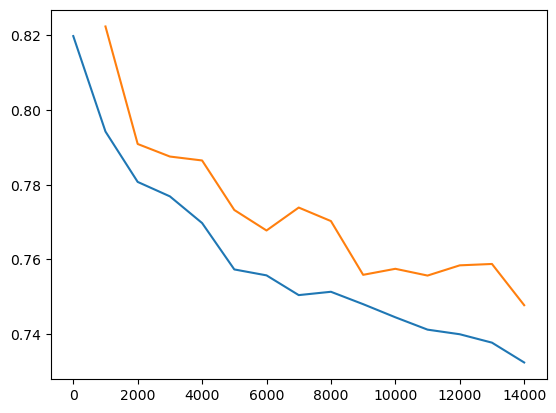

In [274]:
loss_train_bucket_means = []
for i in range(0, len(loss_train), log_every):
  loss_train_bucket_means.append(np.mean(loss_train[i:i+log_every]))

plt.plot([i*1000 for i in range(len(loss_train_bucket_means))], loss_train_bucket_means)
plt.plot([i*1000 for i in range(1, len(loss_val))], loss_val[1:])

plt.show()

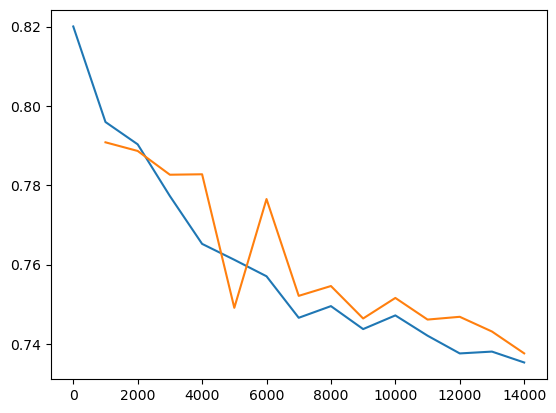

In [147]:
loss_train_bucket_means = []
for i in range(0, len(loss_train), log_every):
  loss_train_bucket_means.append(np.mean(loss_train[i:i+log_every]))

plt.plot([i*1000 for i in range(len(loss_train_bucket_means))], loss_train_bucket_means)
plt.plot([i*1000 for i in range(1, len(loss_val))], loss_val[1:])

plt.show()

# Save the Model

In [275]:
PATH = 'saved_models/20260328_avg_pooling.pth'

torch.save(model.state_dict(), PATH)

# Actually Using the Model

In [276]:
model = MovieRecommender(
    genres_len=len(genres),
    tags_len=len(final_movie_tags),
    top_movies_len=len(top_movies),
    all_years_len=len(year_to_num_movies),
    timestamp_num_bins=timestamp_num_bins,
    item_genre_embedding_size=item_genre_embedding_size,
    item_tag_embedding_size=item_tag_embedding_size,
    item_movieId_embedding_size=item_movieId_embedding_size,
    item_year_embedding_size=item_year_embedding_size,
    user_genre_embedding_size=user_genre_embedding_size,
    timestamp_feature_embedding_size=timestamp_feature_embedding_size,
)
model.load_state_dict(torch.load(PATH, weights_only=True))
model.eval()


MovieRecommender(
  (item_embedding_lookup): Embedding(2269, 40, padding_idx=2268)
  (item_embedding_tower): Sequential(
    (0): Linear(in_features=40, out_features=40, bias=True)
    (1): Tanh()
  )
  (item_genre_tower): Sequential(
    (0): Linear(in_features=20, out_features=10, bias=True)
    (1): Tanh()
  )
  (item_tag_tower): Sequential(
    (0): Linear(in_features=306, out_features=40, bias=True)
    (1): Tanh()
  )
  (year_embedding_lookup): Embedding(192, 10)
  (year_embedding_tower): Sequential(
    (0): Linear(in_features=10, out_features=10, bias=True)
    (1): Tanh()
  )
  (user_genre_tower): Sequential(
    (0): Linear(in_features=20, out_features=50, bias=True)
    (1): Tanh()
  )
  (timestamp_embedding_lookup): Embedding(1500, 10)
  (timestamp_embedding_tower): Sequential(
    (0): Linear(in_features=10, out_features=10, bias=True)
    (1): Tanh()
  )
)

In [277]:
# for every movie, save all its embeddings
movieId_to_embedding = {}

ITEM_EMBEDDING_LOOKUP = model.item_embedding_lookup.weight
YEAR_EMBEDDING_LOOKUP = model.year_embedding_lookup.weight

for movieId in top_movies:
  movieId_to_embedding[movieId] = {}

  item_embedding = ITEM_EMBEDDING_LOOKUP[torch.tensor([item_emb_movieId_to_i[movieId]])]
  movieId_to_embedding[movieId]['MOVIEID_EMBEDDING'] = model.item_embedding_tower(item_embedding)

  year_embedding = YEAR_EMBEDDING_LOOKUP[torch.tensor([year_to_i[movieId_to_year[movieId]]])]
  movieId_to_embedding[movieId]['MOVIE_YEAR_EMBEDDING'] = model.year_embedding_tower(year_embedding)

  movieId_to_embedding[movieId]['MOVIE_GENRE_EMBEDDING'] = model.item_genre_tower(torch.tensor([movieId_to_genre_context[movieId]]))
  movieId_to_embedding[movieId]['MOVIE_TAG_EMBEDDING'] = model.item_tag_tower(torch.tensor([movieId_to_tag_context[movieId]]))

  # compute the combined (concat) item/movie embedding
  item_id_emb = movieId_to_embedding[movieId]['MOVIEID_EMBEDDING']
  item_genre_emb = movieId_to_embedding[movieId]['MOVIE_GENRE_EMBEDDING']
  item_tag_emb = movieId_to_embedding[movieId]['MOVIE_TAG_EMBEDDING']
  iteam_year_emb = movieId_to_embedding[movieId]['MOVIE_YEAR_EMBEDDING']
  movieId_to_embedding[movieId]['MOVIE_EMBEDDING_COMBINED'] = torch.cat((item_genre_emb, item_tag_emb, item_id_emb, iteam_year_emb), dim=1)

In [278]:
for emb_type in movieId_to_embedding[5952].keys():
  print(movieId_to_embedding[5952][emb_type].shape)

torch.Size([1, 40])
torch.Size([1, 10])
torch.Size([1, 10])
torch.Size([1, 40])
torch.Size([1, 100])


### Viewing Movies in 2D

In [ ]:
plt.figure(figsize=(15,15))
for movieId in top_movies[0:25]:
  i = item_emb_movieId_to_i[movieId]
  plt.scatter(ITEM_EMBEDDING_LOOKUP[i,0].data, ITEM_EMBEDDING_LOOKUP[i,1].data, s=200)
  plt.text(ITEM_EMBEDDING_LOOKUP[i,0].item(), ITEM_EMBEDDING_LOOKUP[i,1].item(), movieId_to_title[movieId][0:20], ha="center", va="center", color='black')
plt.grid('minor')

plt.show()

### Finding Most Similar Movies

In [ ]:
# for every movie, and for every embedding type, find the similary to all other embeddings
# NOTE: can be slow
movieId_to_emb_type_to_similarities = {}

for movieId in top_movies:
  movieId_to_emb_type_to_similarities[movieId] = {}

  # for emb_type in movieId_to_embedding[movieId].keys():
  for emb_type in ['MOVIE_EMBEDDING_COMBINED']:
    emb_to_target_to_dist = {}
    for target_id in top_movies:
      src = movieId_to_embedding[movieId][emb_type].view(-1)
      target = movieId_to_embedding[target_id][emb_type].view(-1)

      distance = torch.sqrt(torch.sum(torch.pow(torch.subtract(src, target), 2), dim=0))
      emb_to_target_to_dist[target_id] = distance.item()
    movieId_to_emb_type_to_similarities[movieId][emb_type] = list(sorted(emb_to_target_to_dist.items(), key=lambda item: item[1]))[0:100]

In [ ]:
titles = [
    'Lord of the Rings: The Return of the King, The (2003)',
    'Star Wars: Episode IV - A New Hope (1977)',
    'Toy Story (1995)',
    'Saving Private Ryan (1998)',
    'Kill Bill: Vol. 1 (2003)',
    'American Pie (1999)',
    'Blair Witch Project, The (1999)',
    'Princess Mononoke (Mononoke-hime) (1997)'
]

emb_type = 'MOVIE_EMBEDDING_COMBINED'

table = '| Movie |'
for i in range(5):
  table += ' Similar {} |'.format(i+1)
table += '\n'
for i in range(5):
  table += '|-----'
table += '|\n'

# Print the top most similar movies
for title in titles:
  movieId = title_to_movieId[title]

  table += '| '
  for target_id, dist in movieId_to_emb_type_to_similarities[movieId][emb_type][0:5+1]:
    table += movieId_to_title[target_id] + ' | '
  table += '\n'

print(table)

### Get Recommendations for Users

In [ ]:
for movieId in user_context_movies:
    print(movieId_to_title[movieId], movieId_to_genres[movieId])

In [279]:
user_type_to_favorite_genres = {
    'Fantasy Lover': ['Fantasy'],
    'Children\'s Movie Lover': ['Children'],
    'Horror Lover': ['Horror'],
    'Sci-Fi Lover': ['Sci-Fi'],
    'Comedy Lover': ['Comedy'],
    'Romance Lover': ['Romance'],
    'War Movie Lover': ['War'],

    # profile for myself
    'Myself': ['Fantasy', 'War', 'Horror', 'Drama', 'Action']
}

user_type_to_worst_genres = {
    'Fantasy Lover': ['Horror', 'Children'],
    'Children\'s Movie Lover': ['Horror', 'Romance', 'Drama'],
    'Horror Lover': ['Children'],
    'Sci-Fi Lover': ['Romance', 'Children'],
    'Comedy Lover': ['Children'],
    'Romance Lover': ['Children', 'Horror'],
    'War Movie Lover': ['Children'],

    # profile for myself
    'Myself': ['Romance']
}

user_type_to_favorite_movies = {
    'Fantasy Lover': [
        'Lord of the Rings: The Fellowship of the Ring, The (2001)',
        'Lord of the Rings: The Two Towers, The (2002)',
        'Gladiator (2000)',
        '300 (2007)',
        'Braveheart (1995)'
        ],
    'Children\'s Movie Lover': [
        'Toy Story 2 (1999)',
        'Finding Nemo (2003)',
        'Monsters, Inc. (2001)'
        ],
    'Horror Lover': [
        'Blair Witch Project, The (1999)',
        'Silence of the Lambs, The (1991)',
        'Sixth Sense, The (1999)'
        ],
    'Sci-Fi Lover': [
        'Star Wars: Episode V - The Empire Strikes Back (1980)',
        'Matrix, The (1999)',
        'Terminator, The (1984)'
        ],
    'Comedy Lover': [
        'American Pie (1999)',
        'Dumb & Dumber (Dumb and Dumber) (1994)',
        'Austin Powers: The Spy Who Shagged Me (1999)',
        'Big Lebowski, The (1998)'
      ],
    'Romance Lover': [
        'Shakespeare in Love (1998)',
        'There\'s Something About Mary (1998)',
        'Sense and Sensibility (1995)'
    ],
    'War Movie Lover': [
        'Saving Private Ryan (1998)',
        'Apocalypse Now (1979)',
        'Full Metal Jacket (1987)'
    ],

    # profile for myself
    'Myself': [
        'Lord of the Rings: The Fellowship of the Ring, The (2001)',
        'Lord of the Rings: The Two Towers, The (2002)',
        'Lord of the Rings: The Return of the King, The (2003)',
        '300 (2007)',
        'Saving Private Ryan (1998)',
        'Kill Bill: Vol. 1 (2003)',
    ]
}

value_for_favorite_genre_avg_rating = float(5.0)
value_for_disliked_genre_avg_rating = float(-2.0)
value_for_favorite_movie_rating     = float(2.0)  # debiased rating injected into watch history

user_to_inference_context = {}   # genre context vector (20-dim)
user_to_inference_history = {}   # watch history: list of (emb_idx, movieId) tuples

for user_type in user_type_to_favorite_genres.keys():
    # Genre context: only len(genres) slots now
    inference_user_context = [0.0] * user_context_size

    for genre in user_type_to_favorite_genres[user_type]:
        inference_user_context[user_context_genre_avg_rating_to_i[genre]] = value_for_favorite_genre_avg_rating

    for genre in user_type_to_worst_genres[user_type]:
        inference_user_context[user_context_genre_avg_rating_to_i[genre]] = value_for_disliked_genre_avg_rating

    user_to_inference_context[user_type] = inference_user_context

    # Watch history: favorite movies go here instead of into the genre context vector
    # Only include movies that exist in the item embedding lookup
    history = [
        (item_emb_movieId_to_i[title_to_movieId[title]], title_to_movieId[title])
        for title in user_type_to_favorite_movies[user_type]
        if title_to_movieId[title] in item_emb_movieId_to_i
    ]
    user_to_inference_history[user_type] = history


In [280]:
user_to_top_recs = {}

for user_type in user_to_inference_context.keys():

    # Genre context (20-dim)
    X_inference = torch.tensor([user_to_inference_context[user_type]])
    genre_embedding_inference = model.user_genre_tower(X_inference)

    # Watch history: avg pool of favorite movies' embeddings, weighted equally (rating=1.0)
    history = user_to_inference_history[user_type]
    if len(history) > 0:
        hist_ids     = torch.tensor([h[0] for h in history], dtype=torch.long).unsqueeze(0)  # (1, hist_len)
        hist_weights = torch.ones(1, len(history))                                             # (1, hist_len)
        hist_embs    = model.item_embedding_lookup(hist_ids)                                   # (1, hist_len, emb_dim)
        weight_sum   = hist_weights.unsqueeze(-1).abs().sum(dim=1).clamp(min=1e-6)
        history_emb  = (hist_embs * hist_weights.unsqueeze(-1)).sum(dim=1) / weight_sum        # (1, emb_dim)
    else:
        history_emb = torch.zeros(1, model.item_embedding_lookup.embedding_dim)

    # Timestamp: use most recent timestamp from training data
    timestamp_inference = torch.bucketize(torch.tensor([df_ratings['timestamp'].max()]), timestamp_bins, right=False)
    timestamp_embedding = model.timestamp_embedding_tower(model.timestamp_embedding_lookup(timestamp_inference))

    # Combine user side: history + genre + timestamp
    user_and_timestamp_combined_embedding = torch.cat((history_emb, genre_embedding_inference, timestamp_embedding), dim=1)

    movieId_to_pred_score = {}
    for movieId in top_movies:
        item_embedding_combined_inference = movieId_to_embedding[movieId]['MOVIE_EMBEDDING_COMBINED']
        preds = torch.einsum('ij, ij -> i', user_and_timestamp_combined_embedding, item_embedding_combined_inference)
        movieId_to_pred_score[movieId] = preds

    top_recs = []
    show_top_recs = True
    for movieId, pred_score in list(sorted(movieId_to_pred_score.items(), key=lambda item: item[1], reverse=show_top_recs)):
        if len(top_recs) >= 10: break
        if movieId_to_title[movieId] not in user_type_to_favorite_movies[user_type]:
            top_recs.append(movieId)
    user_to_top_recs[user_type] = top_recs


In [281]:
for user_type in user_to_top_recs.keys():
  print("Hello, " + user_type)
  print("Because you like: [" + ','.join(user_type_to_favorite_genres[user_type]) + ']')
  print("And hate: [" + ','.join(user_type_to_worst_genres[user_type]) + ']')
  print("And enjoyed these movies:")
  for title in user_type_to_favorite_movies[user_type]:
    print(title)
  print()

  print("You should watch:")
  for movieId in user_to_top_recs[user_type]:
    print(movieId_to_title[movieId])
  print()

Hello, Fantasy Lover
Because you like: [Fantasy]
And hate: [Horror,Children]
And enjoyed these movies:
Lord of the Rings: The Fellowship of the Ring, The (2001)
Lord of the Rings: The Two Towers, The (2002)
Gladiator (2000)
300 (2007)
Braveheart (1995)

You should watch:
Spirited Away (Sen to Chihiro no kamikakushi) (2001)
Coraline (2009)
Matilda (1996)
Paprika (Papurika) (2006)
Alice in Wonderland (1951)
Fall, The (2006)
Strictly Ballroom (1992)
Wallace & Gromit: The Best of Aardman Animation (1996)
Shall We Dance? (Shall We Dansu?) (1996)
Your Name. (2016)

Hello, Children's Movie Lover
Because you like: [Children]
And hate: [Horror,Romance,Drama]
And enjoyed these movies:
Toy Story 2 (1999)
Finding Nemo (2003)
Monsters, Inc. (2001)

You should watch:
Harry Potter and the Order of the Phoenix (2007)
Harry Potter and the Sorcerer's Stone (a.k.a. Harry Potter and the Philosopher's Stone) (2001)
Pirates of the Caribbean: On Stranger Tides (2011)
Pirates of the Caribbean: Dead Man's Ches

In [ ]:
# sanity check - make sure we aren't just recommending the higest rated movies
# NOTE: this is an extremely common problem in rec systems as the model learns
# to play it safe and just recommend what almost is highly rated.
for movieId, avg_rating in sorted(movieId_to_avg_rating.items(), key=lambda item: item[1], reverse=True)[0:10]:
  print(movieId_to_title[movieId], avg_rating)

In [171]:
# Finding the 'most representative' movies for a specfic GENRE
genre = 'Horror'
genre_context = [0.0] * len(genres)
genre_context[genre_to_i[genre]] = float(1.0)
genre_context_emb = model.item_genre_tower(torch.tensor([genre_context]))

movieId_to_dist = {}
for movieId in top_movies:
  distance = torch.sqrt(torch.sum(torch.pow(torch.subtract(movieId_to_embedding[movieId]['MOVIE_GENRE_EMBEDDING'].view(-1), genre_context_emb.view(-1)), 2), dim=0))
  movieId_to_dist[movieId] = distance.item()

for movieId,dist in list(sorted(movieId_to_dist.items(), key=lambda item: item[1]))[0:10]:
    print(movieId_to_title[movieId])

Shining, The (1980)
Get Out (2017)
Halloween (1978)
Nosferatu (Nosferatu, eine Symphonie des Grauens) (1922)
It (2017)
Texas Chainsaw Massacre, The (1974)
Pet Sematary (1989)
It Follows (2014)
The Witch (2015)
Hellraiser (1987)


In [172]:
# Finding the 'most representative' movies for a specfic TAG
tags = ['horror', 'gore', 'torture']
tags = ['dystopia', 'artificial intelligence', 'martial arts']
tag_context = [0.0] * len(final_movie_tags)
for tag in tags:
  tag_context[tag_to_i[tag]] = float(10.0)
tag_context_emb = model.item_tag_tower(torch.tensor([tag_context]))

movieId_to_dist = {}
for movieId in top_movies:
  distance = torch.sqrt(torch.sum(torch.pow(torch.subtract(movieId_to_embedding[movieId]['MOVIE_TAG_EMBEDDING'].view(-1), tag_context_emb.view(-1)), 2), dim=0))
  movieId_to_dist[movieId] = distance.item()

for movieId,dist in list(sorted(movieId_to_dist.items(), key=lambda item: item[1]))[0:10]:
    print(movieId_to_title[movieId])

Escape from L.A. (1996)
RoboCop 2 (1990)
Star Trek III: The Search for Spock (1984)
Siege, The (1998)
Karate Kid, Part III, The (1989)
Avengers, The (1998)
Jaws 2 (1978)
Young Guns II (1990)
City Slickers II: The Legend of Curly's Gold (1994)
Money Train (1995)
